<a href="https://colab.research.google.com/github/owais8-lang/231A057-NLP_experiments/blob/main/NLPexp10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Name:Ansari Mohd Owais","UIN:231A057")
import pandas as pd
from datasets import load_dataset

# Load complete IMDB dataset
dataset = load_dataset("stanfordnlp/imdb")

# Combine train and test
df = pd.concat(
    [dataset["train"].to_pandas(),
     dataset["test"].to_pandas()],
    ignore_index=True
)

# Rename target column
df = df.rename(columns={"label": "labels"})

print(df.shape)
print(df.columns)
print(df["labels"].value_counts())

Name:Ansari Mohd Owais UIN:231A057


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

(50000, 2)
Index(['text', 'labels'], dtype='object')
labels
0    25000
1    25000
Name: count, dtype: int64


In [2]:
print("Name:Ansari Mohd Owais","UIN:231A057")
df['labels']

Name:Ansari Mohd Owais UIN:231A057


,labels
0,0
1,0
2,0
3,0
4,0
...,...
49995,1
49996,1
49997,1
49998,1


In [3]:
print("Name:Ansari Mohd Owais","UIN:231A057")
# ------------------------------------------------------------
# 2. CHECK MISSING VALUES AND DUPLICATES
# ------------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


# ------------------------------------------------------------
# 3. BASIC TEXT STATISTICS
# ------------------------------------------------------------

# Using "text" instead of the non-existent "review" column
df["char_count"] = df["text"].astype(str).apply(len)

df["word_count"] = df["text"].astype(str).apply(
    lambda x: len(x.split())
)

df["unique_word_count"] = df["text"].astype(str).apply(
    lambda x: len(set(x.lower().split()))
)

df["avg_word_length"] = df["text"].astype(str).apply(
    lambda x: sum(len(word) for word in x.split()) /
              max(len(x.split()), 1)
)

print("\nText Statistics:")
df[
    ["char_count",
     "word_count",
     "unique_word_count",
     "avg_word_length"]
].describe()

Name:Ansari Mohd Owais UIN:231A057

Missing values:
text      0
labels    0
dtype: int64

Number of duplicate rows:
418

Text Statistics:


,char_count,word_count,unique_word_count,avg_word_length
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1309.431020,231.156940,148.049780,4.640676
std,989.728014,171.343997,88.837364,0.340731
min,32.000000,4.000000,4.000000,1.239865
25%,699.000000,126.000000,91.000000,4.417904
50%,970.000000,173.000000,120.000000,4.627006
75%,1590.250000,280.000000,180.000000,4.847458
max,13704.000000,2470.000000,1092.000000,12.290909


In [4]:
print("Name:Ansari Mohd Owais","UIN:231A057")
import re

def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep alphabetic characters only
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Using 'text' instead of the non-existent 'review' column
df["clean_text"] = df["text"].astype(str).apply(clean_text)
# Using 'text' instead of the non-existent 'review' column
df["clean_text"] = df["text"].astype(str).apply(clean_text)

print("\nOriginal Review:")
print(df["text"].iloc[0][:500])

print("\nCleaned Review:")
print(df["clean_text"].iloc[0][:500])

Name:Ansari Mohd Owais UIN:231A057

Original Review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Cleaned Review:
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in i also heard that at first it was seized by u s customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself the plot is centered around a young swedish drama student named lena who wants to learn everything she can about 

Name:Ansari Mohd Owais UIN:231A057


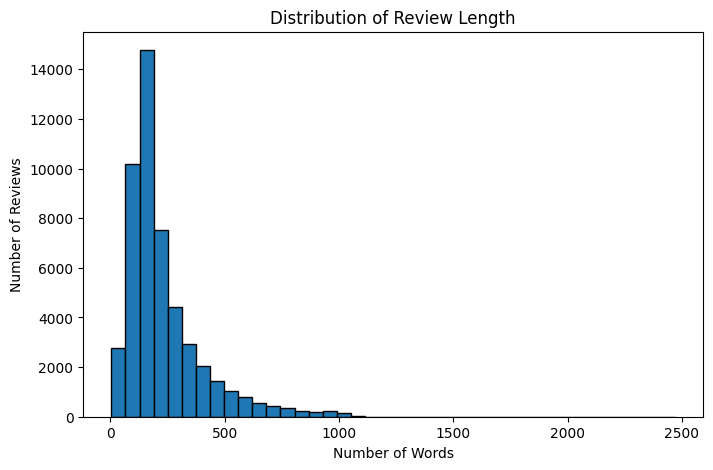

Total number of words: 11709196


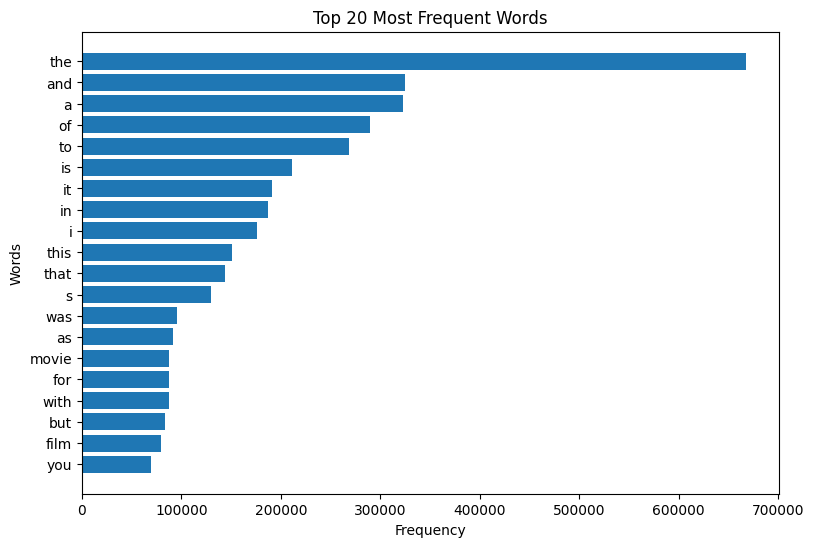

In [5]:
print("Name:Ansari Mohd Owais","UIN:231A057")
import matplotlib.pyplot as plt
from collections import Counter

# ------------------------------------------------------------
# 5. DOCUMENT LENGTH DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["word_count"], bins=40, edgecolor="black")

plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Review Length")

plt.show()


# ------------------------------------------------------------
# 6. CREATE WORD LIST
# ------------------------------------------------------------

# Fixed: Changed "clean_review" to "clean_text"
all_words = " ".join(df["clean_text"]).split()

print("Total number of words:", len(all_words))


# ------------------------------------------------------------
# 7. MOST FREQUENT WORDS
# ------------------------------------------------------------

word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(9, 6))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words")

plt.show()

Name:Ansari Mohd Owais UIN:231A057


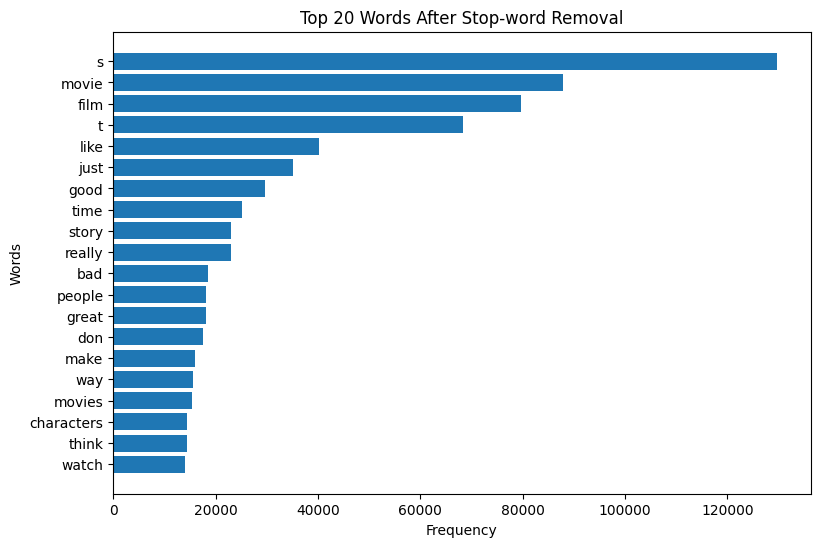

In [6]:
print("Name:Ansari Mohd Owais","UIN:231A057")
from sklearn.feature_extraction.text import CountVectorizer

# ------------------------------------------------------------
# 8. REMOVE STOP WORDS
# ------------------------------------------------------------

vectorizer = CountVectorizer(
    stop_words="english"
)

# Fixed: Changed "clean_review" to "clean_text"
vectorizer.fit(df["clean_text"])

stop_words = vectorizer.get_stop_words()

filtered_words = [
    word for word in all_words
    if word not in stop_words
]

filtered_freq = Counter(filtered_words)

top_filtered = filtered_freq.most_common(20)

words = [word for word, count in top_filtered]
counts = [count for word, count in top_filtered]

plt.figure(figsize=(9, 6))

plt.barh(words[::-1], counts[::-1])

plt.xlabel("Frequency")
plt.ylabel("Words")
plt.title("Top 20 Words After Stop-word Removal")

plt.show()

Name:Ansari Mohd Owais UIN:231A057


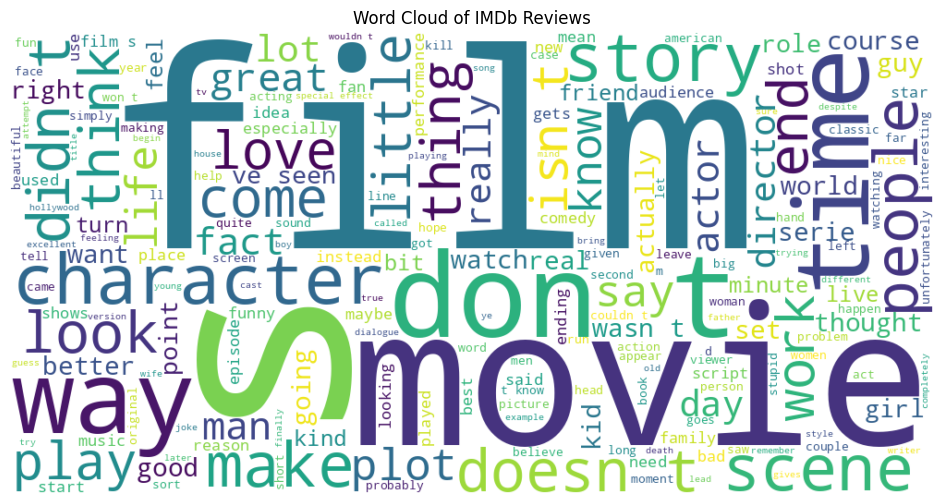

In [7]:
print("Name:Ansari Mohd Owais","UIN:231A057")
from wordcloud import WordCloud

# ------------------------------------------------------------
# 9. WORD CLOUD
# ------------------------------------------------------------

clean_text_combined = " ".join(filtered_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(clean_text_combined)

plt.figure(figsize=(12, 6))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of IMDb Reviews")

plt.show()

In [8]:
print("Name:Ansari Mohd Owais","UIN:231A057")
# ------------------------------------------------------------
# 10. BIGRAM ANALYSIS
# ------------------------------------------------------------

bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

# Fixed: Changed "clean_review" to "clean_text"
bigram_matrix = bigram_vectorizer.fit_transform(
    df["clean_text"]
)

bigram_counts = bigram_matrix.sum(axis=0).A1
bigram_names = bigram_vectorizer.get_feature_names_out()

bigram_df = pd.DataFrame({
    "Bigram": bigram_names,
    "Frequency": bigram_counts
})

# Get the top bigram with the highest frequency
top_bigram = bigram_df.sort_values(by="Frequency", ascending=False).iloc[0]
print(f"\nTop Bigram: '{top_bigram['Bigram']}' with a frequency of {top_bigram['Frequency']}")

Name:Ansari Mohd Owais UIN:231A057

Top Bigram: 've seen' with a frequency of 4168
